# **T03 - Griegas y aproximación del valor de una opción**
## **Simulación de Procesos Financieros**

---

**Autor:** Francisco Uriel Ledezma Chávez  
**Carrera:** Ingeniería Financiera  
**Institución:** ITESO — Universidad Jesuita de Guadalajara  
**Semestre:** 5° — Simulación de Procesos Financieros  
**Fecha de realización:** 20 de septiembre de 2026

---

**Ejercicio:** argumentar decisiones financieras a partir de las sensibilidades del precio de una opción, a lo largo de tres partes que consisten en leer tres contratos distintos únicamente por sus griegas, elegir cuál comprar y cuál evitar en cinco escenarios de mercado, y medir hasta dónde las griegas de un solo día describen la trayectoria del valor a lo largo de seis meses.

El notebook anterior mostró que las griegas son derivadas parciales que reproducen con precisión la forma cerrada cuando se calculan sobre una malla fina, mientras que aquí la pregunta se invierte y se vuelve mucho más exigente, ya que se trata de saber qué tanto sirven cinco sensibilidades del día inicial para predecir el valor de la opción cuando el precio, la volatilidad y el plazo se mueven todos al mismo tiempo durante medio año, y la respuesta termina siendo una lección sobre el alcance de una aproximación local.

## Índice de contenidos

1. Sección 1 — Observación de las tres opciones
2. Sección 2 — Escenarios de mercado
3. Sección 3 — Aproximación por griegas
4. Sección 4 — Valuación por simulación y forma cerrada
5. Sección 5 — Comparación del error y trayectoria
6. Sección 6 — Lectura del error
7. Sección 7 — Conclusiones

## Importación de bibliotecas

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

np.random.seed(20)

## 1. Observación de las tres opciones

Una institución financiera emite tres calls sobre una acción que cotiza en 100 pesos, descritas sin fórmula alguna y sólo por su prima y sus sensibilidades, de modo que toda la lectura debe salir de esos números.

| Opción | $K$ | $T$ | Prima | Delta | Vega | Theta |
|---|---|---|---|---|---|---|
| **A** | 90 | 1/12 | 12 | 0.85 | 0.05 | −0.10 |
| **B** | 100 | 3/12 | 8 | 0.50 | 0.25 | −0.03 |
| **C** | 120 | 1 | 5 | 0.20 | 0.40 | −0.01 |

La unidad de theta debe fijarse antes de cualquier lectura, ya que la tercera parte del ejercicio sí la declara anualizada y aquí no, y con la acción en 100 la opción A tiene 10 pesos de valor intrínseco y por lo tanto sólo 2 pesos de valor temporal, cifra que un theta de −0.10 diarios consume casi exactamente a lo largo de los veintiún días hábiles que le restan, coincidencia que confirma la expresión por día hábil y que se sostiene en todo lo que sigue.

La descomposición de cada prima entre valor intrínseco y valor temporal ordena el resto del análisis.

In [2]:
opciones = pd.DataFrame({
    'Opción': ['A', 'B', 'C'],
    'K': [90, 100, 120],
    'T (años)': [1/12, 3/12, 1.0],
    'Prima': [12.0, 8.0, 5.0],
    'Delta': [0.85, 0.50, 0.20],
    'Vega': [0.05, 0.25, 0.40],
    'Theta': [-0.10, -0.03, -0.01],
})

S_spot = 100
opciones['Intrínseco'] = np.maximum(S_spot - opciones['K'], 0)
opciones['Temporal'] = opciones['Prima'] - opciones['Intrínseco']
opciones['Días hábiles'] = (opciones['T (años)'] * 252).round().astype(int)
opciones['Theta total'] = opciones['Theta'] * opciones['Días hábiles']
opciones['Theta / Temporal'] = (opciones['Theta total'] / opciones['Temporal']).round(3)

opciones.round(4)

,Opción,K,T (años),Prima,Delta,Vega,Theta,Intrínseco,Temporal,Días hábiles,Theta total,Theta / Temporal
0,A,90,0.0833,12.0,0.85,0.05,-0.10,10,2.0,21,-2.10,-1.050
1,B,100,0.2500,8.0,0.50,0.25,-0.03,0,8.0,63,-1.89,-0.236
2,C,120,1.0000,5.0,0.20,0.40,-0.01,0,5.0,252,-2.52,-0.504


La tabla vuelve explícito el contraste, ya que la opción A es casi la acción disfrazada de opción, con diez de sus doce pesos en valor intrínseco y sólo dos sujetos al paso del tiempo, mientras que B y C no tienen valor intrínseco alguno y su prima entera es una apuesta sobre lo que falta por ocurrir.

La última columna mide el desgaste acumulado de theta contra el valor temporal que cada contrato tiene para perder, y ahí A resulta la más expuesta con un cociente de −1.05, es decir, su theta alcanza a consumir la totalidad de ese valor antes del vencimiento, mientras B pierde 1.89 pesos de los 8 que tiene en juego y C pierde 2.52 de 5, aunque en ambos casos la cifra subestima el desgaste real porque theta se acelera conforme el plazo se acorta y aquí se extrapola el valor de hoy sobre toda la vida del contrato.

**1. ¿Cuál opción parece más sensible a cambio en el precio de la acción?** La opción A, con delta de 0.85, ya que por cada peso que suba la acción su prima avanza 85 centavos contra los 50 de B y los 20 de C, comportamiento que se explica porque A está profundamente dentro del dinero y le quedan veintiún días hábiles, de modo que su probabilidad de ejercerse es alta y el contrato se mueve casi a la par del subyacente.

**2. ¿Cuál opción parece más sensible a cambios en volatilidad?** La opción C, con vega de 0.40, ya que un punto porcentual adicional de volatilidad le agrega 40 centavos a una prima de 5 pesos, es decir, un 8% de su valor, mientras que ese mismo punto le agrega apenas 0.4% a la prima de A, y la razón es que vega alcanza su máximo cuando el desenlace resulta más incierto, condición que C reúne por partida doble con el strike más lejano y el plazo más largo.

**3. ¿Cuál opción parece deteriorarse más rápidamente con el paso del tiempo?** La opción A, con theta de −0.10 diarios, que en términos absolutos pierde más de tres veces lo que pierde B y diez veces lo que pierde C, aunque el dato decisivo es el relativo, ya que esos diez centavos diarios se descuentan de los dos únicos pesos de valor temporal que tiene y por ello A pierde 5% de lo que está en riesgo cada día que pasa.

**4. ¿Cuál opción parece tener el comportamiento más parecido al de la acción?** La opción A, y la conclusión se sostiene en dos griegas y no en una, ya que su delta de 0.85 la acerca a la unidad que tendría la acción misma y su vega de 0.05 indica que casi no responde a la volatilidad, que es precisamente la característica que distingue a una opción de su subyacente, de modo que una posición en A es en los hechos una posición apalancada en la acción con fecha de caducidad.

**5. ¿Cuál opción parece depender más de que ocurra un evento importante en el futuro?** La opción C, donde las cuatro cifras apuntan en la misma dirección, ya que necesita que la acción suba 20% para siquiera alcanzar el strike, su delta de 0.20 confirma que el mercado le asigna una probabilidad baja de lograrlo, sus 5 pesos son íntegramente valor temporal y su vega de 0.40 es la más alta de las tres, con lo cual comprar C es comprar la posibilidad de que algo cambie de manera sustancial durante el año y no la expectativa de una trayectoria en particular.

## 2. Escenarios de mercado

Cada escenario se resuelve identificando primero cuál sensibilidad gobierna el resultado y eligiendo después el contrato que la maximiza sin cargar con las otras, aunque debe advertirse desde ahora que los tres instrumentos son calls, de modo que en los escenarios bajistas ninguna elección es buena y el ejercicio consiste en reconocer cuál pierde menos y por qué.

**Escenario A. La acción sube gradualmente durante los próximos meses y la volatilidad no cambia.**

Compraría **B** y evitaría **C**, porque la tentación de elegir A por su delta de 0.85 se desarma al notar que el escenario dura meses mientras A vence en veintiún días hábiles y expiraría antes de capturar la subida, en tanto que B sobrevive el horizonte con tres meses de plazo, aporta una delta de 0.50 que sí participa del movimiento y arrastra un theta de −0.03 diarios tolerable frente a los 8 pesos de prima, mientras C se descarta porque una subida gradual difícilmente cubre la distancia de 20% que la separa del strike y su vega de 0.40, que es la mitad de su atractivo, no aporta nada cuando la volatilidad permanece quieta.

**Escenario B. En dos semanas la empresa anuncia un producto nuevo y se espera un movimiento brusco de dirección desconocida.**

Compraría **C** y evitaría **A**, ya que la dirección se desconoce y eso convierte a la delta en un pasivo en lugar de una ventaja, porque una delta alta castiga con la misma intensidad si el precio cae, de modo que C resulta apropiada al ofrecer la mayor vega y la menor delta y capturar así el encarecimiento de la volatilidad implícita que suele preceder a un anuncio sin comprometerse con una dirección, mientras A es justamente el contrato opuesto, pues su delta de 0.85 la vuelve una apuesta direccional encubierta y además pierde 0.10 diarios durante las dos semanas de espera, es decir, un peso entero de sus dos pesos de valor temporal antes de que el evento siquiera ocurra.

**Escenario C. La acción se mantiene muy estable.**

Compraría **A** y evitaría **C**, aunque la respuesta honesta es que ninguna compra tiene sentido y la posición correcta sería vender volatilidad en lugar de comprarla, ya que entre las tres A resulta la menos dañina porque diez de sus doce pesos son valor intrínseco y ese componente no depende de que ocurra nada, con lo cual el daño se limita a los dos pesos de valor temporal, mientras C representa el peor caso posible al ser sus 5 pesos enteramente valor temporal y vega, de manera que una acción inmóvil la lleva a expirar sin valor y la pérdida resulta total.

**Escenario D. Se espera una caída significativa del precio.**

Compraría **C** y evitaría **A**, con la misma advertencia de que el instrumento adecuado sería una put y no una call, ya que C pierde 20 centavos por cada peso de caída y es la menor exposición de las tres, además de que su vega de 0.40 la compensa parcialmente porque las caídas suelen venir acompañadas de un alza de la volatilidad implícita, mientras A es la elección más costosa al perder 85 centavos por peso y ver evaporarse sus diez pesos de valor intrínseco si la acción retrocede por debajo de 90.

**Escenario E. El mercado está subestimando la incertidumbre futura.**

Compraría **C** y evitaría **A**, ya que este escenario es una posición pura sobre vega al afirmar que la volatilidad implícita está barata sin decir nada sobre la dirección del precio, y C concentra la mayor vega junto con el plazo más largo, combinación que importa porque vega se desvanece conforme el vencimiento se acerca y un año de plazo mantiene viva la exposición el tiempo suficiente para que la tesis se materialice, mientras A resulta inservible para esta idea con una vega de 0.05 que apenas registra el cambio y un theta que cobra 0.10 diarios por esperar.

## 3. Aproximación por griegas

La tercera parte cambia de objeto, ya que ahora hay una sola call con strike de 100, vencimiento en octubre y una tasa libre de riesgo de 5%, de la cual se dispone de seis observaciones mensuales del precio y de la volatilidad además del valor y las cuatro sensibilidades del día inicial, con lo cual la pregunta es si eso basta para reconstruir la trayectoria.

La aproximación encadena el desarrollo de Taylor de segundo orden en el precio y de primer orden en la volatilidad y el tiempo, tomando siempre las griegas de mayo.

$$V_t = V_{t-1} + \Delta\, dS + \tfrac{1}{2}\Gamma\,(dS)^2 + \nu\, d\sigma + \Theta\, dt$$

$$dS = S_t - S_{t-1}, \qquad d\sigma = \sigma_t - \sigma_{t-1}, \qquad dt = \tfrac{1}{12}$$

Dos convenciones quedan fijadas por los propios datos, ya que la volatilidad se mide en puntos porcentuales porque una vega de 0.2814 multiplicada por un cambio de 5 puntos produce 1.41 pesos, magnitud consistente con el problema, mientras que interpretarla en decimales daría 1.4 centavos y volvería irrelevante a vega, y por su parte theta viene anualizada, de modo que su contribución mensual equivale a un doceavo.

In [3]:
meses = ['Mayo', 'Junio', 'Julio', 'Agosto', 'Septiembre', 'Octubre']
precio = np.array([100, 102, 101, 105, 103, 110], dtype=float)
volatilidad = np.array([20, 25, 30, 28, 22, 20], dtype=float)   # puntos porcentuales

K, r = 100.0, 0.05
V0, DELTA, GAMMA, VEGA, THETA = 6.8887, 0.5977, 0.02736, 0.2814, -8.116
dt = 1/12

dS = np.concatenate(([np.nan], np.diff(precio)))
dsigma = np.concatenate(([np.nan], np.diff(volatilidad)))

valor_greeks = [V0]
for i in range(1, len(meses)):
    incremento = (DELTA * dS[i]
                  + 0.5 * GAMMA * dS[i]**2
                  + VEGA * dsigma[i]
                  + THETA * dt)
    valor_greeks.append(valor_greeks[-1] + incremento)
valor_greeks = np.array(valor_greeks)

tabla_greeks = pd.DataFrame({
    'Mes': meses,
    'Precio': precio,
    'Volatilidad': volatilidad,
    'dS': dS,
    'dsigma': dsigma,
    'Valor aproximado (Greeks)': valor_greeks,
})
tabla_greeks.round(4)

,Mes,Precio,Volatilidad,dS,dsigma,Valor aproximado (Greeks)
0,Mayo,100.0,20.0,NaN,NaN,6.8887
1,Junio,102.0,25.0,2.0,5.0,8.8695
2,Julio,101.0,30.0,-1.0,5.0,9.0161
3,Agosto,105.0,28.0,4.0,-2.0,10.3867
4,Septiembre,103.0,22.0,-2.0,-6.0,6.8813
5,Octubre,110.0,20.0,7.0,-2.0,10.4964


Los datos de partida deben verificarse antes de leer la tabla, ya que el ejercicio entrega cinco cifras que deberían ser consistentes entre sí bajo Black-Scholes con la acción en 100, strike de 100, volatilidad de 20%, plazo de medio año y tasa de 5%.

In [4]:
def black_scholes_call(S, K, r, sigma, T):
    d1 = (np.log(S/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    return S*norm.cdf(d1) - K*np.exp(-r*T)*norm.cdf(d2)


def griegas_call(S, K, r, sigma, T):
    d1 = (np.log(S/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    return {
        'Delta': norm.cdf(d1),
        'Gamma': norm.pdf(d1) / (S*sigma*np.sqrt(T)),
        'Vega': S*norm.pdf(d1)*np.sqrt(T) / 100,
        'Theta': -S*norm.pdf(d1)*sigma/(2*np.sqrt(T)) - r*K*np.exp(-r*T)*norm.cdf(d2),
    }


g_mayo = griegas_call(100, K, r, 0.20, 6/12)
verificacion = pd.DataFrame({
    'Dada por el ejercicio': [V0, DELTA, GAMMA, VEGA, THETA],
    'Black-Scholes': [black_scholes_call(100, K, r, 0.20, 6/12),
                      g_mayo['Delta'], g_mayo['Gamma'], g_mayo['Vega'], g_mayo['Theta']],
}, index=['V0', 'Delta', 'Gamma', 'Vega', 'Theta'])
verificacion['Diferencia'] = verificacion['Black-Scholes'] - verificacion['Dada por el ejercicio']
verificacion.round(5)

,Dada por el ejercicio,Black-Scholes,Diferencia
V0,6.88870,6.88873,0.00003
Delta,0.59770,0.59773,0.00003
Gamma,0.02736,0.02736,-0.00000
Vega,0.28140,0.27359,-0.00781
Theta,-8.11600,-8.11597,0.00003


Cuatro de las cinco cifras coinciden con la forma cerrada hasta el quinto decimal, lo cual confirma que el punto de partida es una call de Black-Scholes valuada exactamente en esas condiciones, con vega como única excepción al registrar 0.2814 contra los 0.2736 que arroja la fórmula, una diferencia de 2.85% que no se explica por redondeo ni por ninguna convención alternativa, ya que ni la diferencia finita hacia adelante ni la centrada ni un cambio de base de tiempo reproducen ese valor, de manera que la aproximación se construye con la vega que da el ejercicio, tal como se pide, y la sección 6 mide cuánto de la discrepancia final proviene de ahí.

La trayectoria aproximada arranca en 6.8887 y sube a 8.8695 en junio, donde el alza de 2 pesos en el precio y de 5 puntos en la volatilidad se suman en la misma dirección, mientras julio resulta el mes más revelador del mecanismo, ya que el precio retrocede un peso y aun así el valor aproximado sube a 9.0161 porque la volatilidad avanza otros 5 puntos y su contribución de 1.41 pesos supera con holgura los 60 centavos que cuesta la caída del subyacente.

Septiembre produce el desplome de la serie, con el valor cayendo a 6.8813 debido a que los dos peores términos coinciden, ya que el precio baja 2 pesos y la volatilidad se derrumba 6 puntos, de modo que delta y vega restan 1.20 y 1.69 pesos respectivamente, mientras octubre recupera hasta 10.4964 impulsado por un salto de 7 pesos en el precio, el movimiento más grande de toda la muestra, que por sí solo aporta 4.18 pesos vía delta y otros 0.67 vía gamma.

## 4. Valuación por simulación y forma cerrada

El contraste exige un valor de referencia, y para construirlo se revalúa la call en cada mes desde cero usando el precio y la volatilidad vigentes junto con el plazo que realmente falta para el vencimiento de octubre, cálculo que se hace por dos vías, ya que la primera simula 10,000 escenarios del precio al vencimiento mediante movimiento browniano geométrico y promedia el pago descontado, tal como pide el ejercicio, mientras la segunda evalúa la fórmula de Black-Scholes, que en este caso existe en forma cerrada y no arrastra error de muestreo.

In [5]:
tiempo_restante = np.array([6, 5, 4, 3, 2, 1]) / 12
n_escenarios = 10000

valor_mc, valor_bs = [], []
for i in range(len(meses)):
    S_i, sigma_i, T_i = precio[i], volatilidad[i]/100, tiempo_restante[i]
    S_T = S_i * np.exp((r - 0.5*sigma_i**2)*T_i
                       + sigma_i*np.sqrt(T_i)*np.random.normal(0, 1, n_escenarios))
    valor_mc.append(np.exp(-r*T_i) * np.maximum(S_T - K, 0).mean())
    valor_bs.append(black_scholes_call(S_i, K, r, sigma_i, T_i))

valor_mc, valor_bs = np.array(valor_mc), np.array(valor_bs)

tabla_valuacion = pd.DataFrame({
    'Mes': meses,
    'Precio': precio,
    'Volatilidad': volatilidad,
    'Tiempo restante': [f'{n}/12' for n in [6, 5, 4, 3, 2, 1]],
    'Monte Carlo (10,000)': valor_mc,
    'Valor Black-Scholes': valor_bs,
})
tabla_valuacion['Ruido de simulación'] = np.abs(valor_mc - valor_bs)
tabla_valuacion.round(4)

,Mes,Precio,Volatilidad,Tiempo restante,"Monte Carlo (10,000)",Valor Black-Scholes,Ruido de simulación
0,Mayo,100.0,20.0,6/12,7.0370,6.8887,0.1483
1,Junio,102.0,25.0,5/12,8.5536,8.6621,0.1085
2,Julio,101.0,30.0,4/12,8.3555,8.2860,0.0695
3,Agosto,105.0,28.0,3/12,9.5323,9.3418,0.1905
4,Septiembre,103.0,22.0,2/12,5.9438,5.8530,0.0909
5,Octubre,110.0,20.0,1/12,10.5481,10.5202,0.0279


Las dos vías coinciden en el orden de magnitud y describen la misma trayectoria, aunque no resultan intercambiables para lo que sigue, ya que la simulación con 10,000 escenarios se aparta de la forma cerrada hasta en 0.1905 pesos en agosto y ese ruido no es despreciable frente al error que se quiere medir, pues representa cerca de la quinta parte de la discrepancia máxima entre las griegas y el valor verdadero, mientras en mayo la brecha alcanza 0.1483 pesos aun cuando el valor exacto se conoce de antemano y vale 6.8887, lo cual deja ver que el error proviene íntegramente del muestreo.

Por esa razón la comparación de la siguiente sección se hace contra la forma cerrada y no contra la simulación, ya que medir el error de una aproximación contra un patrón que trae su propio ruido mezclaría dos fuentes distintas y volvería imposible atribuir la discrepancia, además de que el ejercicio ancla la serie en 6.8887, cifra que corresponde exactamente al valor de Black-Scholes y no al de ninguna corrida simulada.

La trayectoria verdadera baja de 6.8887 en mayo a 5.8530 en septiembre y repunta hasta 10.5202 en octubre, último salto que admite una lectura financiera clara, ya que con la acción en 110 y el strike en 100 la opción termina 10 pesos dentro del dinero y le queda un mes de vida, de modo que su valor es casi puro valor intrínseco y la volatilidad deja de importar.

## 5. Comparación del error y trayectoria

La comparación enfrenta la serie construida con las griegas de mayo contra la revaluación exacta de cada mes, y el error absoluto mide la distancia entre ambas.

In [6]:
comparacion = pd.DataFrame({
    'Mes': meses,
    'Greeks': valor_greeks,
    'Black-Scholes': valor_bs,
})
comparacion['Error Absoluto'] = np.abs(comparacion['Greeks'] - comparacion['Black-Scholes'])
comparacion['Error Relativo'] = comparacion['Error Absoluto'] / comparacion['Black-Scholes']
comparacion.round(4)

,Mes,Greeks,Black-Scholes,Error Absoluto,Error Relativo
0,Mayo,6.8887,6.8887,0.0000,0.0000
1,Junio,8.8695,8.6621,0.2074,0.0239
2,Julio,9.0161,8.2860,0.7301,0.0881
3,Agosto,10.3867,9.3418,1.0449,0.1118
4,Septiembre,6.8813,5.8530,1.0283,0.1757
5,Octubre,10.4964,10.5202,0.0239,0.0023


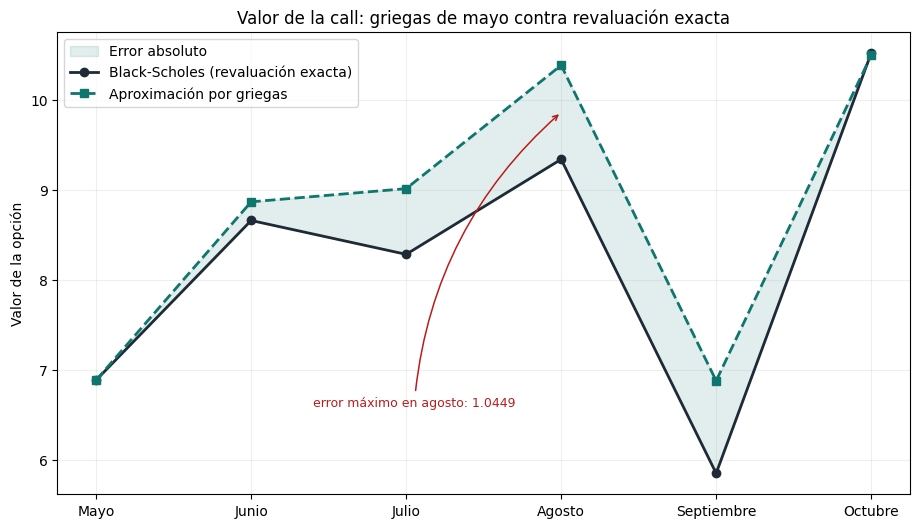

In [7]:
ANCLA, ACENTO, MARCA = '#1f2a37', '#0f766e', '#b91c1c'
x = np.arange(len(meses))
peor = int(np.argmax(comparacion['Error Absoluto'].values))

plt.figure(figsize=(11, 6))
plt.fill_between(x, valor_greeks, valor_bs, color=ACENTO, alpha=0.12, label='Error absoluto')
plt.plot(x, valor_bs, color=ANCLA, marker='o', linewidth=2, label='Black-Scholes (revaluación exacta)')
plt.plot(x, valor_greeks, color=ACENTO, marker='s', linestyle='--', linewidth=2, label='Aproximación por griegas')
plt.annotate(f'error máximo en {meses[peor].lower()}: {comparacion["Error Absoluto"][peor]:.4f}',
             xy=(peor, (valor_greeks[peor] + valor_bs[peor])/2),
             xytext=(peor - 1.6, 6.6), color=MARCA, fontsize=9,
             arrowprops=dict(arrowstyle='->', color=MARCA, lw=1.1,
                             connectionstyle='arc3,rad=-0.2'))
plt.xticks(x, meses)
plt.ylabel('Valor de la opción')
plt.title('Valor de la call: griegas de mayo contra revaluación exacta')
plt.legend()
plt.grid(alpha=0.2)
plt.show()

La figura muestra dos series que arrancan juntas por construcción y se separan de inmediato, ya que la aproximación se mantiene por encima de la curva exacta en los primeros cuatro meses y sólo la cruza al final, lo cual indica que el error no es ruido alrededor del valor verdadero sino un sesgo con dirección constante, señal de que algún término está mal medido de manera sistemática y no de que la aproximación simplemente pierda precisión.

El error crece de 0.2074 en junio a 1.0449 en agosto, máximo de la serie que representa 11.2% del valor exacto de ese mes, mientras septiembre queda prácticamente empatado con 1.0283 y en términos relativos resulta el peor de todos con 17.6%, ya que el denominador es el valor más bajo de la trayectoria.

Octubre exige una lectura cuidadosa, porque el error se desploma a 0.0239 y la tentación es concluir que la aproximación se recuperó, cuando no ocurrió nada de eso, ya que las dos curvas se cruzan debido a que el sesgo positivo acumulado durante cinco meses queda cancelado por el error de signo contrario que introduce el salto de 7 pesos en el precio, y la sección siguiente descompone esa cancelación para mostrar que se trata de una coincidencia aritmética y no de una mejora del método.

## 6. Lectura del error

Las preguntas de cierre se responden con tres cálculos adicionales, ya que el primero recupera las griegas verdaderas de cada mes y las contrasta contra las que la aproximación mantiene congeladas, el segundo separa el error de cada mes en las tres variables que se mueven comparando el cambio exacto que produce cada una contra el término que la griega le asigna, y el tercero rehace la serie con la vega de la forma cerrada para aislar cuánto de la discrepancia proviene del dato inconsistente y cuánto del método.

In [8]:
griegas_reales = pd.DataFrame(
    [griegas_call(precio[i], K, r, volatilidad[i]/100, tiempo_restante[i]) for i in range(len(meses))],
    index=meses)
griegas_reales.loc['Congeladas (mayo)'] = [DELTA, GAMMA, VEGA, THETA]
griegas_reales.round(5)

,Delta,Gamma,Vega,Theta
Mayo,0.59773,0.02736,0.27359,-8.11597
Junio,0.63024,0.02293,0.24854,-10.23736
Julio,0.59494,0.02216,0.22601,-12.76076
Agosto,0.69420,0.02386,0.18411,-13.48764
Septiembre,0.67968,0.03867,0.15044,-13.13654
Octubre,0.96010,0.01354,0.02731,-8.03148
Congeladas (mayo),0.59770,0.02736,0.28140,-8.11600


In [9]:
filas = []
for i in range(1, len(meses)):
    s_ant, v_ant, T_ant = precio[i-1], volatilidad[i-1]/100, tiempo_restante[i-1]
    base = black_scholes_call(s_ant, K, r, v_ant, T_ant)
    solo_S = black_scholes_call(precio[i], K, r, v_ant, T_ant)
    mas_sigma = black_scholes_call(precio[i], K, r, volatilidad[i]/100, T_ant)
    mas_T = black_scholes_call(precio[i], K, r, volatilidad[i]/100, tiempo_restante[i])
    filas.append({
        'Mes': meses[i],
        'Error por precio': (DELTA*dS[i] + 0.5*GAMMA*dS[i]**2) - (solo_S - base),
        'Error por volatilidad': VEGA*dsigma[i] - (mas_sigma - solo_S),
        'Error por tiempo': THETA*dt - (mas_T - mas_sigma),
    })

descomposicion = pd.DataFrame(filas).set_index('Mes')
descomposicion.loc['Suma del periodo'] = descomposicion.sum()
descomposicion.round(4)

,Error por precio,Error por volatilidad,Error por tiempo
Mes,,,
Junio,0.0010,0.0598,0.1466
Julio,0.0346,0.1506,0.3375
Agosto,0.0588,-0.1307,0.3866
Septiembre,0.1986,-0.5509,0.3357
Octubre,-0.7002,-0.3993,0.0473
Suma del periodo,-0.4072,-0.8704,1.2537


In [10]:
VEGA_CERRADA = g_mayo['Vega']

valor_vega_corregida = [V0]
for i in range(1, len(meses)):
    valor_vega_corregida.append(valor_vega_corregida[-1]
                                + DELTA*dS[i] + 0.5*GAMMA*dS[i]**2
                                + VEGA_CERRADA*dsigma[i] + THETA*dt)
valor_vega_corregida = np.array(valor_vega_corregida)

efecto_vega = pd.DataFrame({
    'Mes': meses,
    'Error con vega dada (0.2814)': np.abs(valor_greeks - valor_bs),
    f'Error con vega cerrada ({VEGA_CERRADA:.5f})': np.abs(valor_vega_corregida - valor_bs),
})
efecto_vega['Reducción'] = (efecto_vega.iloc[:, 1] - efecto_vega.iloc[:, 2])
efecto_vega.round(4)

,Mes,Error con vega dada (0.2814),Error con vega cerrada (0.27359),Reducción
0,Mayo,0.0000,0.0000,0.0000
1,Junio,0.2074,0.1683,0.0391
2,Julio,0.7301,0.6520,0.0781
3,Agosto,1.0449,0.9824,0.0625
4,Septiembre,1.0283,1.0127,0.0156
5,Octubre,0.0239,0.0239,-0.0000


**1. ¿Los greeks iniciales describen con precisión toda la trayectoria?** No, ya que describen bien el primer paso y se degradan con rapidez a partir del segundo, con un error de 0.2074 pesos en junio que equivale al 2.4% del valor exacto y que para agosto alcanza 1.0449 pesos y 11.2%, degradación que la tabla de griegas verdaderas explica al mostrar que ninguna de las cuatro se mantiene en su valor de mayo, pues delta sube de 0.5977 a 0.9601 conforme la opción se adentra en el dinero, vega se derrumba de 0.2736 a 0.0273 porque la volatilidad deja de importar cuando queda un mes de plazo, y theta pasa de −8.116 a −13.488 en agosto antes de regresar a −8.031, de modo que la aproximación aplica en octubre las sensibilidades de una opción que ya no existe.

**2. ¿En qué mes apareció el error más grande?** En agosto, con 1.0449 pesos en términos absolutos, aunque septiembre queda a 0.0166 de distancia con 1.0283 y lo supera en términos relativos con 17.6% contra 11.2%, y ambos meses comparten la misma causa, ya que a esas alturas se han acumulado tres y cuatro aplicaciones de un theta congelado que subestima el desgaste real del plazo.

**3. ¿Qué factor parece contribuir más al error?** El tiempo, y la descomposición lo cuantifica sin ambigüedad, ya que el término de theta aporta un error acumulado de +1.2537 pesos siempre del mismo signo, contra −0.8704 del término de volatilidad y −0.4072 del término de precio, diferencia que se explica porque theta se acelera conforme el vencimiento se acerca mientras la aproximación descuenta invariablemente los 0.676 pesos que corresponden a un doceavo de −8.116, de modo que cada mes se queda corta entre 0.0473 y 0.3866 pesos y ese faltante se acumula sin compensarse nunca, origen del sesgo positivo que se observa en la gráfica.

La vega inconsistente de la sección 3 contribuye también, aunque en segundo plano, ya que rehacer la serie con la vega cerrada de 0.27359 reduce el error de agosto de 1.0449 a 0.9824 pesos y explica apenas el 6% de la discrepancia de ese mes, de manera que el problema de fondo no está en el dato sino en el método.

**4. ¿Por qué los Greeks funcionan mejor para movimientos pequeños que para movimientos grandes?** Porque una aproximación de Taylor descarta los términos de orden superior, cuyo peso crece con una potencia del tamaño del movimiento, y como el término que se conserva en el precio es de segundo orden el primero descartado escala con el cubo de dS, contraste que la descomposición vuelve nítido al mostrar que en junio, con un movimiento de 2 pesos, el término de delta y gamma se equivoca por 0.0010 pesos, mientras en octubre, con un movimiento de 7 pesos, se equivoca por 0.7002, de modo que el movimiento creció tres veces y media y el error creció setecientas, justamente lo que anticipa una dependencia cúbica.

**5. Si la trayectoria fuera mucho más volátil, ¿esperarías errores menores?** No, mayores, y por la misma razón del punto anterior, ya que una trayectoria más agitada produce valores de dS más grandes en cada paso y el error del término de precio escala con el cubo de esa magnitud, de modo que la degradación avanza mucho más rápido que el movimiento que la provoca, efecto que además se compone porque precios más dispersos alejan la opción de su condición inicial y dejan a las griegas congeladas todavía más lejos de las verdaderas.

In [11]:
print(f"{'Factor':>8} {'|dS| promedio':>15} {'Error máximo':>14}")
for factor in [0.5, 1.0, 2.0, 3.0]:
    precio_k = 100 + factor * (precio - 100)
    v = [V0]
    for i in range(1, len(meses)):
        d = precio_k[i] - precio_k[i-1]
        v.append(v[-1] + DELTA*d + 0.5*GAMMA*d**2 + VEGA*dsigma[i] + THETA*dt)
    exacto = np.array([black_scholes_call(precio_k[i], K, r, volatilidad[i]/100, tiempo_restante[i])
                       for i in range(len(meses))])
    print(f"{factor:>8.1f} {np.abs(np.diff(precio_k)).mean():>15.2f} {np.abs(np.array(v) - exacto).max():>14.4f}")

  Factor   |dS| promedio   Error máximo
     0.5            1.60         0.9935
     1.0            3.20         1.0449
     2.0            6.40         1.6456
     3.0            9.60         2.6705


La prueba confirma la respuesta y agrega un matiz que no debe pasarse por alto, ya que amplificar los movimientos del precio al doble eleva el error máximo de 1.0449 a 1.6456 pesos y al triple lo lleva hasta 2.6705, degradación clara y más que proporcional, mientras reducir los movimientos a la mitad apenas baja el error a 0.9935 porque el componente que domina la discrepancia es el de theta y ese término no depende del precio en absoluto, de manera que una trayectoria más volátil empeora las cosas pero una trayectoria más tranquila no las arregla.

## 7. Conclusiones

Las griegas de un solo día describen bien el paso siguiente y mal el horizonte completo, y la frontera entre ambos regímenes resulta sorprendentemente cercana, ya que el error de junio es de 0.2074 pesos sobre un valor de 8.6621 y resulta tolerable para cualquier uso práctico, mientras dos meses después alcanza 1.0449 sobre 9.3418 y para septiembre representa 17.6% del valor del contrato, comportamiento esperable si se recuerda que una sensibilidad es una derivada, es decir, una afirmación sobre el precio en la vecindad inmediata de un punto, de modo que usarla a seis meses de distancia equivale a extrapolar una recta tangente muy lejos del lugar donde toca la curva.

El desgaste del tiempo es el término que más daño hace, y la razón está en que es el único que se mueve en una sola dirección, ya que theta aporta un error acumulado de +1.2537 pesos contra −0.8704 de vega y −0.4072 de delta y gamma, no porque su magnitud sea mayor en un mes cualquiera sino porque nunca cambia de signo, de modo que lo que subestima cada mes se suma sin cancelarse, mientras los errores de precio y volatilidad alternan según la dirección del movimiento y se compensan parcialmente entre sí.

La cancelación de octubre ilustra el riesgo de evaluar una aproximación por su resultado final, ya que el error cae a 0.0239 pesos, la cifra más baja de toda la serie, y sería fácil concluir que el método funciona bien a seis meses, cuando la descomposición muestra lo contrario al revelar que ese número surge de restar un sesgo acumulado de +1.25 por theta contra un error de −0.70 que el salto de 7 pesos introduce en el término de precio, de manera que dos errores grandes de signo opuesto produjeron un error pequeño y la única forma de distinguir eso de una aproximación genuinamente buena es abrir la descomposición.

El límite del método es estructural y no se arregla con mejores datos, ya que la vega que entrega el ejercicio está 2.85% por encima de la que corresponde a Black-Scholes y corregirla reduce el error de agosto sólo de 1.0449 a 0.9824 pesos, apenas un 6%, con lo cual el problema no es la calidad de las cinco cifras iniciales sino que sean cinco cifras fijas aplicadas a un contrato que cambia de naturaleza, pues la opción de octubre tiene delta de 0.9601 y vega de 0.0273, es decir, es casi una posición en la acción, mientras la aproximación sigue tratándola como la opción en el dinero que era en mayo.

La extensión natural es actualizar las griegas en cada paso en lugar de congelarlas, lo cual convierte la aproximación en un esquema de integración numérica y elimina el sesgo de theta, aunque exige revaluar el contrato cada mes y con ello desaparece buena parte de la ventaja de usar sensibilidades, intercambio que el ejercicio deja ver con claridad, ya que las griegas son un atajo para preguntas locales y cuando la pregunta deja de ser local hay que volver a valuar.